In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from google.colab import drive

# 1. Mount Drive
drive.mount('/content/drive')

# 2. Updated path
file_path = '/content/drive/MyDrive/Assignment 4 /q2_customers.csv'

# 3. Load the data
df = pd.read_csv(file_path)

# 4. Success check
print("Q2 Data Loaded Successfully!")
display(df.head())

# Task 1: Scaling (As discussed previously)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)
df_scaled = pd.DataFrame(scaled_data, columns=df.columns)
print("\nFirst 5 rows of scaled data:")
display(df_scaled.head())

Mounted at /content/drive
Q2 Data Loaded Successfully!


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1



First 5 rows of scaled data:


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-0.725219,-0.176150,0.110166,-0.265011,-0.089951,0.550952
1,-1.488460,-1.046826,0.486157,-0.980466,-0.835176,-0.680685
2,0.176795,0.267337,-0.453822,-0.236851,-0.674046,-0.270139
3,-0.725219,-1.012309,0.298161,-0.827783,-0.996306,-1.091230
4,-1.488460,-1.034488,1.426136,-1.005986,-0.653905,-1.501776


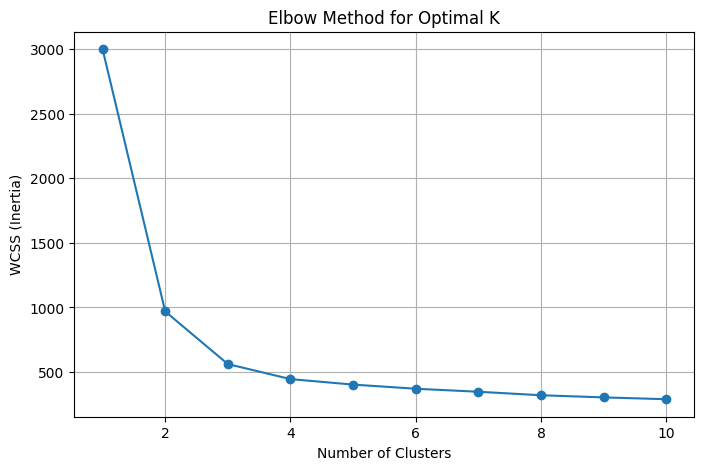

In [3]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
for i in range(1, 11):
    # n_init='auto' or 10 is good practice in newer versions
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)
plt.show()

Explained Variance Ratio: [0.83560354 0.05568764]

--- Feature Loadings ---


,PC1,PC2
age,0.411569,-0.259432
annual_spend,0.421540,-0.033270
visits_per_month,-0.410399,0.208318
basket_size,0.412012,-0.195402
days_since_last_visit,0.378582,0.911194
num_categories_purchased,0.414017,-0.140479


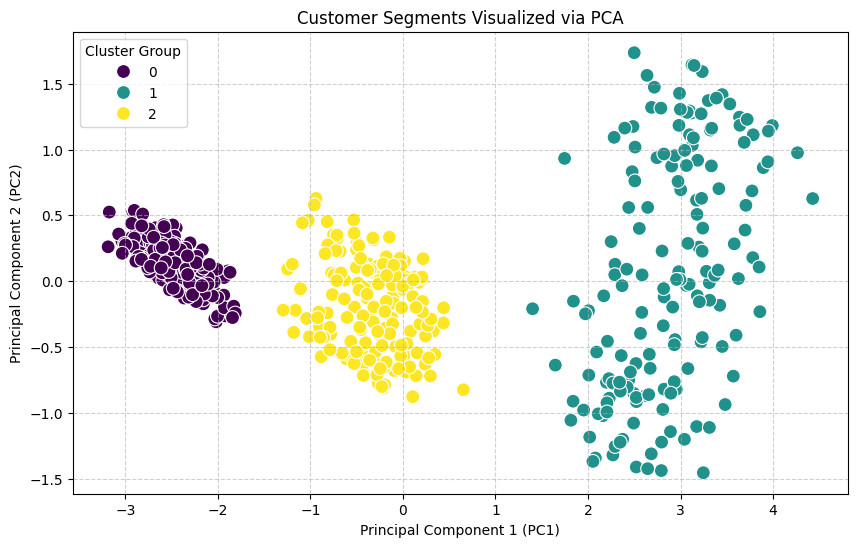

In [6]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# --- TASK 4: PCA Calculation ---
# 1. Define and apply PCA to your scaled data
pca = PCA(n_components=2)
pca_data = pca.fit_transform(df_scaled) # <--- This defines 'pca_data'

# 2. Print Variance
print(f"Explained Variance Ratio: {pca.explained_variance_ratio_}")

# 3. Create Feature Loadings Dataframe
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=df.columns[:-1] # Exclude the cluster column
)
print("\n--- Feature Loadings ---")
display(loadings)


# --- TASK 5: Visualization ---
plt.figure(figsize=(10, 6))

# Use pca_data[:, 0] for X and pca_data[:, 1] for Y
sns.scatterplot(
    x=pca_data[:, 0],
    y=pca_data[:, 1],
    hue=df['cluster'],
    palette='viridis',
    s=100
)

plt.title('Customer Segments Visualized via PCA')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.legend(title='Cluster Group')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()